In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from utils.dfCleaning import Cleaning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor

------------
# Data Preprocessing
------------

In [24]:
df = pd.read_csv('../data/movies.csv')
df = Cleaning(df)
df

,Movie,Director,Running time,Actor 1,Actor 2,Actor 3,Genre,Budget,Box Office,Actors Box Office %,Director Box Office %,Earnings,Oscar and Golden Globes nominations,Oscar and Golden Globes awards,Release year,IMDb score
0,13 Hours,Michael Bay,144,Toby Stephens,James Badge Dale,David Costabile,Action,50000000,69400000,50.00,69.23,19400000,0,0.0,2016,7.4
1,16 Blocks,Richard Donner,102,Bruce Willis,David Zayas,Sasha Roiz,Action,52000000,65000000,33.33,50.00,13000000,0,0.0,2006,6.6
2,17 Again,Burr Steers,102,Matthew Perry,Hunter Parrish,Thomas Lennon,Comedy,20000000,139000000,44.44,25.00,119000000,0,0.0,2009,6.4
3,1982,Tommy Oliver,90,Bokeem Woodbine,Ruby Dee,Quinton Aaron,Drama,1000000,2000000,50.00,100.00,1000000,0,0.0,2013,7.1
4,2 Fast 2 Furious,John Singleton,107,Paul Walker,Cole Hauser,Mo Gallini,Action,76000000,236000000,75.00,42.85,160000000,0,0.0,2003,5.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3897,Z Storm,David Lam,92,Michael Wong,Louis Koo,Stephen Au,Action,7000000,17000000,100.00,100.00,10000000,0,0.0,2014,5.3
3898,Zack and Miri Make a Porno,Kevin Smith,101,Gerry Bednob,Jeff Anderson,Jennifer Schwalbach Smith,Comedy,24000000,42000000,66.67,41.66,18000000,0,0.0,2008,6.6
3899,Zero Effect,Jake Kasdan,116,Kim Dickens,Ryan O'Neal,Angela Featherstone,Comedy,5000000,2000000,33.33,50.00,-3000000,0,0.0,1998,7.0
3900,Zombieland,Ruben Fleischer,88,Emma Stone,Bill Murray,Derek Graf,Adventure,23600000,102000000,66.67,33.33,78400000,0,0.0,2009,7.7


In [25]:
df.columns.tolist()

['Movie',
 'Director',
 'Running time',
 'Actor 1',
 'Actor 2',
 'Actor 3',
 'Genre',
 'Budget',
 'Box Office',
 'Actors Box Office %',
 'Director Box Office %',
 'Earnings',
 'Oscar and Golden Globes nominations',
 'Oscar and Golden Globes awards',
 'Release year',
 'IMDb score']

### Creating Features For The Model

In [26]:
features = ['Running time',
            'Budget',
            'Actors Box Office %',
            'Director Box Office %',
            'Release year',
            'Oscar and Golden Globes nominations',
            'Oscar and Golden Globes awards',
            'Genre',
            'Actor 1',
            'Actor 2',
            'Actor 3']

In [27]:
X = df[features]
y = df['IMDb score']

In [28]:
X

,Running time,Budget,Actors Box Office %,Director Box Office %,Release year,Oscar and Golden Globes nominations,Oscar and Golden Globes awards,Genre,Actor 1,Actor 2,Actor 3
0,144,50000000,50.00,69.23,2016,0,0.0,Action,Toby Stephens,James Badge Dale,David Costabile
1,102,52000000,33.33,50.00,2006,0,0.0,Action,Bruce Willis,David Zayas,Sasha Roiz
2,102,20000000,44.44,25.00,2009,0,0.0,Comedy,Matthew Perry,Hunter Parrish,Thomas Lennon
3,90,1000000,50.00,100.00,2013,0,0.0,Drama,Bokeem Woodbine,Ruby Dee,Quinton Aaron
4,107,76000000,75.00,42.85,2003,0,0.0,Action,Paul Walker,Cole Hauser,Mo Gallini
...,...,...,...,...,...,...,...,...,...,...,...
3897,92,7000000,100.00,100.00,2014,0,0.0,Action,Michael Wong,Louis Koo,Stephen Au
3898,101,24000000,66.67,41.66,2008,0,0.0,Comedy,Gerry Bednob,Jeff Anderson,Jennifer Schwalbach Smith
3899,116,5000000,33.33,50.00,1998,0,0.0,Comedy,Kim Dickens,Ryan O'Neal,Angela Featherstone
3900,88,23600000,66.67,33.33,2009,0,0.0,Adventure,Emma Stone,Bill Murray,Derek Graf


In [29]:
y.value_counts()

IMDb score
6.7    183
6.6    163
6.5    154
6.4    151
7.2    150
      ... 
1.6      1
9.1      1
3.2      1
2.6      1
2.0      1
Name: count, Length: 77, dtype: int64

In [30]:
num_features = ['Running time',
                'Budget',
                'Actors Box Office %',
                'Oscar and Golden Globes awards',
                'Oscar and Golden Globes nominations',
                'Director Box Office %',
                'Release year']

cat_features = ['Genre',
                'Actor 1',
                'Actor 2',
                'Actor 3']

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [34]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3121, 5794), (781, 5794), (3121,), (781,))

------------
# Model Training and Evaluation
------------

In [35]:
regressor = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=6,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    objective="reg:squarederror",
    random_state=42
)


In [36]:
regressor.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Evaluating the trained model on training data


In [37]:
y_train_pred = regressor.predict(X_train)
mae = mean_absolute_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)
print(f'Training Mean Absolute Error: {mae}')
print(f'Training R-squared: {r2}')

Training Mean Absolute Error: 0.44132256061745856
Training R-squared: 0.7061904547101253


### Evaluating the trained model on testing data


In [38]:
y_pred = regressor.predict(X_test)

In [39]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Testing Mean Absolute Error: {mae}')
print(f'Testing R-squared: {r2}')

Testing Mean Absolute Error: 0.6166849735909632
Testing R-squared: 0.41795561950362337


In [40]:
print(y_test.head(10).values)
print(y_pred[:10])

[6.  7.5 4.7 5.2 7.2 7.6 7.4 6.3 6.5 6.7]
[5.799828  6.6603665 5.437243  5.345307  7.487359  6.836989  7.3656664
 5.66459   5.612667  6.8695407]


In [41]:
print(y_pred.min())
print(y_pred.max())

3.0049028
8.437083


------------
# Visualizing Model Performance
------------

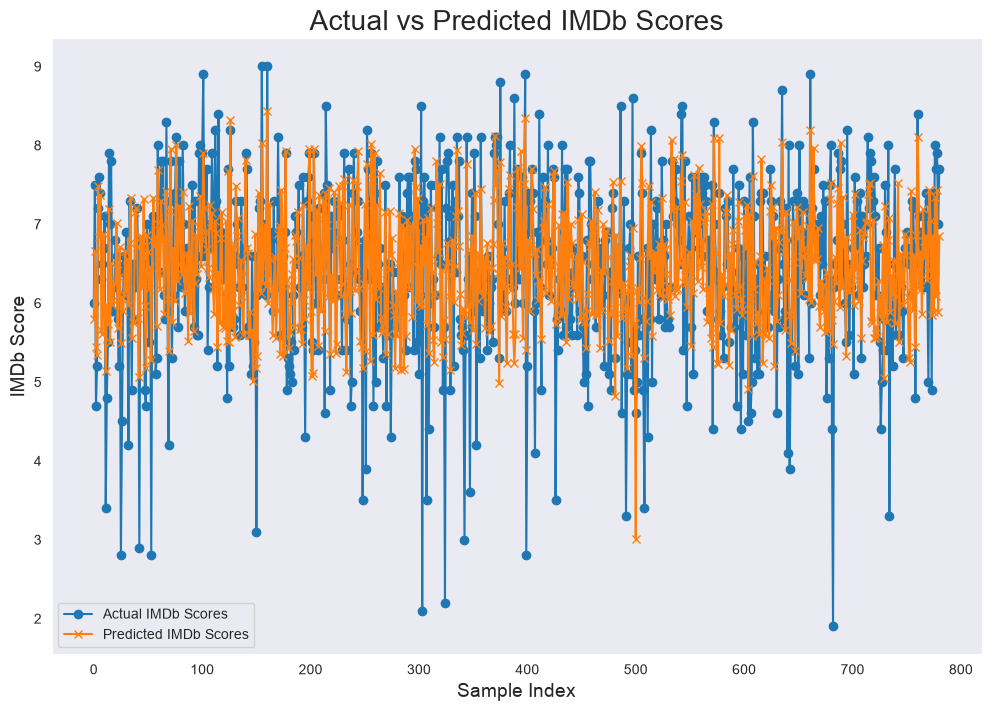

In [42]:
plt.figure(figsize=(12, 8))
plt.plot(y_test.values, label='Actual IMDb Scores', marker='o')
plt.plot(y_pred, label='Predicted IMDb Scores', marker='x')
plt.title('Actual vs Predicted IMDb Scores', fontsize=20)
plt.xlabel('Sample Index', fontsize=14)
plt.ylabel('IMDb Score', fontsize=14)
plt.legend()
plt.grid()
plt.show()

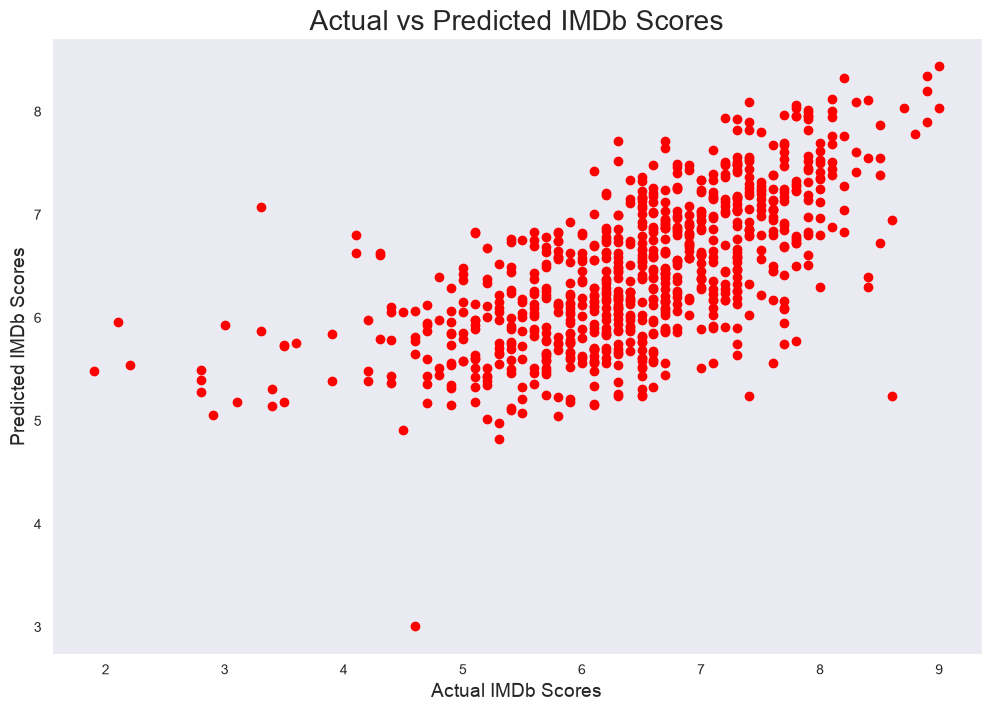

In [43]:
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred, color='red')
plt.title('Actual vs Predicted IMDb Scores', fontsize=20)
plt.xlabel('Actual IMDb Scores', fontsize=14)
plt.ylabel('Predicted IMDb Scores', fontsize=14)
plt.grid()
plt.show()